In [11]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Parameters
# -----------------------------
dt = 0.01       # ms
T_equil = 100   # ms
T_sim = 150     # ms

Cm = 1.0        # uF/cm^2
gL = 0.1        # mS/cm^2
gNa = 100.0     # mS/cm^2
gKdr = 20       # mS/cm^2
gKHT = 500      # mS/cm^2

EL = -65.0      # mV, leak reversal potential
ENa = 55.0      # mV
EK = -80.0      # mV
EE = 0.0        # mV, excitatory synaptic reversal potential
EI = -75.0      # mV, inhibitory synaptic reversal potential

tau_w = 1.0     # ms, time constant for H-current gating variable
tau_E = 5.0     # ms
tau_I = 5.0     # ms


I_values = np.arange(10.0, 100.0 + 0.1, 5.0)


In [13]:

def I_ext_time(t, I_amp):
    """
    Current injection starts at 50 ms and stops at 100 ms.
    """
    if 50.0 <= t < 100.0:
        return I_amp
    return 0.0

def safe_rate(x, scale=10.0):
    """
    Computes x / (1 - exp(-x/scale)) safely.
    Limit as x -> 0 is scale.
    """
    if abs(x) < 1e-8:
        return scale
    return x / (1.0 - np.exp(-x / scale))


def hvcI_rhs(t, y, I_amp):
    """
    Right-hand side for HVC(I).

    y = [V, m, h, n, w, gE, gI]
    """

    # V is membrane potential, m/h/n are gating variables for Na/K channels, w is the gating variable for the H-current, and gE/gI are the excitatory/inhibitory synaptic conductances.
    V, m, h, n, w, gE, gI = y
    
    Iext = I_ext_time(t, I_amp)

    # -----------------------------
    # Ionic currents
    # -----------------------------
    IL = gL * (EL - V)
    INa = gNa * m**3 * h * (ENa - V)
    IKdr = gKdr * n**4 * (EK - V)
    IKHT = gKHT * w * (EK - V)

    # -----------------------------
    # Synaptic currents
    # -----------------------------
    IExc = gE * (EE - V)
    IInh = gI * (EI - V)

    # Voltage equation
    dVdt = (IL + INa + IKdr + IKHT + IExc + IInh + Iext) / Cm

    # -----------------------------
    # Gating kinetics
    # -----------------------------

    # sodium activation m
    alpha_m = safe_rate(V + 22.0, scale=10.0)
    beta_m = 40.0 * np.exp(-(V + 47.0) / 18.0)

    # sodium inactivation h
    alpha_h = 0.7 * np.exp(-(V + 34.0) / 20.0)
    beta_h = 10.0 / (1.0 + np.exp(-(V + 4.0) / 10.0))

    # delayed-rectifier potassium activation n
    alpha_n = 0.15 * safe_rate(V + 15.0, scale=10.0)
    beta_n = 0.2 * np.exp(-(V + 25.0) / 80.0)

    dmdt = alpha_m * (1.0 - m) - beta_m * m
    dhdt = alpha_h * (1.0 - h) - beta_h * h
    dndt = alpha_n * (1.0 - n) - beta_n * n

    # high-threshold potassium activation w
    w_inf = 1.0 / (1.0 + np.exp(-V / 5.0))
    dwdt = (w_inf - w) / tau_w

    # synaptic conductance decay
    dgEdt = -gE / tau_E
    dgIdt = -gI / tau_I
   
    
    return np.array([dVdt, dmdt, dhdt, dndt, dwdt, dgEdt, dgIdt])    


def rk4_step(t, y, dt, I_amp):
    """
    One fourth-order Runge-Kutta step.
    """
    k1 = hvcI_rhs(t, y, I_amp)
    k2 = hvcI_rhs(t + dt/2, y + dt*k1/2, I_amp)
    k3 = hvcI_rhs(t + dt/2, y + dt*k2/2, I_amp)
    k4 = hvcI_rhs(t + dt, y + dt*k3, I_amp)

    return y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)


In [14]:
def initial_conditions():
    V0 = EL

    alpha_m = safe_rate(V0 + 22.0, scale=10.0)
    beta_m = 40.0 * np.exp(-(V0 + 47.0) / 18.0)
    m0 = alpha_m / (alpha_m + beta_m)

    alpha_h = 0.07 * np.exp(-(V0 + 34.0) / 20.0)
    beta_h = 10.0 / (1.0 + np.exp(-(V0 + 4.0) / 10.0))
    h0 = alpha_h / (alpha_h + beta_h)

    alpha_n = 0.15 * safe_rate(V0 + 15.0, scale=10.0)
    beta_n = 0.2 * np.exp(-(V0 + 25.0) / 80.0)
    n0 = alpha_n / (alpha_n + beta_n)

    w0 = 1.0 / (1.0 + np.exp(-V0 / 5.0))

    gE0 = 0.0
    gI0 = 0.0

    return np.array([V0, m0, h0, n0, w0, gE0, gI0])

def equilibrate():
    y = initial_conditions()
    t = 0.0

    for _ in range(int(T_equil / dt)):
        y = rk4_step(t, y, dt, I_amp=0.0)
        t += dt

    return y

def simulate(I_amp, y0):
    t_arr = np.arange(0.0, T_sim + dt, dt)
    y_arr = np.zeros((len(t_arr), len(y0)))

    y = y0.copy()

    for i, t in enumerate(t_arr):
        y_arr[i] = y
        y = rk4_step(t, y, dt, I_amp)

    V = y_arr[:, 0]
    return t_arr, V, y_arr

def count_spikes(t, V, threshold=0.0):
    """
    Counts upward crossings of threshold during 50-100 ms.
    """
    crossings = np.where(
        (V[:-1] < threshold) &
        (V[1:] >= threshold) &
        (t[1:] >= 50.0) &
        (t[1:] < 100.0)
    )[0]

    return len(crossings)

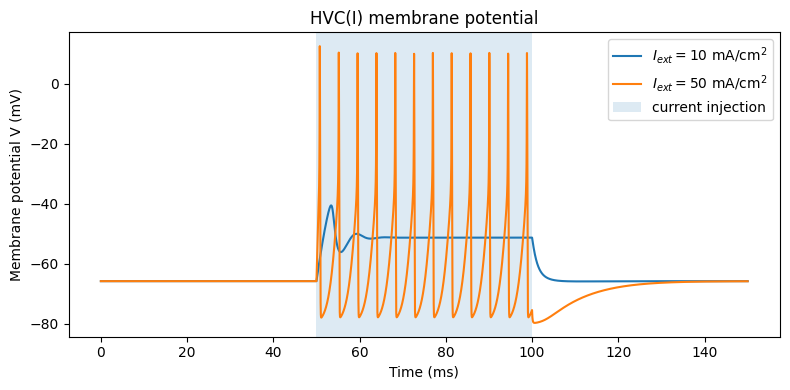

In [15]:
y_eq = equilibrate()

plt.figure(figsize=(8, 4))

for I_amp in [10.0, 50.0]:
    t, V, y_all = simulate(I_amp, y_eq)
    plt.plot(t, V, label=fr"$I_{{ext}} = {I_amp:.0f}$ mA/cm$^2$")

plt.axvspan(50, 100, alpha=0.15, label="current injection")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("HVC(I) membrane potential")
plt.legend()
plt.tight_layout()
plt.show()

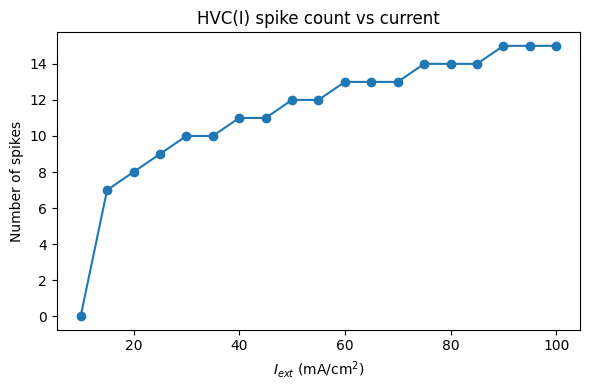

In [16]:
I_values = np.arange(10.0, 100.0 + 0.1, 5.0)
spike_counts = []

for I_amp in I_values:
    t, V, y_all = simulate(I_amp, y_eq)
    n_spikes = count_spikes(t, V, threshold=0.0)
    spike_counts.append(n_spikes)

spike_counts = np.array(spike_counts)

plt.figure(figsize=(6, 4))
plt.plot(I_values, spike_counts, "o-")
plt.xlabel(r"$I_{ext}$ (mA/cm$^2$)")
plt.ylabel("Number of spikes")
plt.title("HVC(I) spike count vs current")
plt.tight_layout()
plt.show()